# Lactic acid case study

This notebook reproduces the continuous lactic acid fermentation case study of Gordeeva et al. (2019) and demonstrates physiological thresholds for two-stage viability.

We:
- Implement the effective substrate feed to account for precursor-to-substrate conversion.
- Embed their kinetics in our two-stage framework 
- Quantify physiological thresholds where two-stage beats one-stage STY
- Demonstrate framework utility for any published one-stage model


## Imports and environment setup

In [1]:
import numpy as np
import pandas as pd
import plotly.graph_objects as go
import ContiDesigner

ContiModel = ContiDesigner.ContiModel
ContiSolver = ContiDesigner.Solver
ContiPlotter = ContiDesigner.Plotter
DEFAULT_PROCESSES = ContiDesigner.DEFAULT_PROCESSES
from ContiDesigner.plot import colors


## Effective substrate feed $S_{F,\text{eff}}(D)$

Gordeeva et al. include a precursor pool $M$ with feed concentration $M_0$ that converts to substrate with rate constant $k_M$. To avoid overestimating substrate inhibition by directly adding $M_0$ to the substrate feed, we use a dilution-rate–dependent effective feed:

$
S_{F,\text{eff}}(D) = S_F + \frac{k_M M_0}{D + k_M}.
$

The helper function below implements this relation.


In [2]:
def effective_substrate_feed(D, S_F=60.0, k_M=0.035, M0=20.0):
    """
    Effective substrate feed concentration S_F,eff(D) [g/L].
    """
    D = np.asarray(D, dtype=float)
    return S_F + k_M * M0 / (D + k_M)

## Configure one-stage model

We start from the lactic acid entry in `DEFAULT_PROCESSES` and configure the one-stage system

We instantiate two variants:
- A “baseline” case with $Y_{P/S} = 1\ \text{g/g}$.
- A “decoupled” case with $Y_{P/S} = 100\ \text{g/g}$ used to match Gordeeva et al., where substrate consumption is effectively only linked to growth.


In [3]:
def setup_os_variant(params, Yps):
    """
    Create model, solver, and plotter with specified Yps.

    Parameters
    ----------
    params : dict
        Base parameter dictionary.
    Yps : float
        Product yield on substrate in stage 1 [g/g].

    Returns
    -------
    model : ContiModel
    solver : ContiSolver
    plotter : ContiPlotter
    """
    params_ = params.copy()
    params_["Yps_1"] = Yps
    model = ContiModel(params_)
    solver = ContiSolver(model)
    plotter = ContiPlotter(model, solver)
    return model, solver, plotter

# Core parameter set matching Gordeeva et al.
# All parameters are directly taken from the paper, no fitting necessary
params = DEFAULT_PROCESSES["LA"]

# Use D_os=0.1 only for effective substrate feed calculation
# This deliberate simplification for D-sweeps reproduces Gordeeva curves accurately.
D_os = 0.1  # 1/h
params["sf1"] = float(effective_substrate_feed(D_os))

# Base variant: Yps_1 = 1 g/g
model_os_base, solver_os_base, plotter_os_base = setup_os_variant(params, Yps=1)

# Decoupled variant: Yps_1 = 100 g/g (decoupled substrate usage for product)
model_os_decoupled, solver_os_decoupled, plotter_os_decoupled = setup_os_variant(params, Yps=100)

In [4]:
def load_gordeeva_curves(P_path="P.tsv", X_path="X.tsv", STY_path="STY.tsv"):
    """
    Load digitized Gordeeva et al. curves from TSV files.

    Returns
    -------
    X_df, P_df, STY_df : pandas.DataFrame
        DataFrames with columns 'x' (D) and 'y' (quantity).
    """
    P_df = pd.read_csv(P_path, sep="\t").sort_values(by="x")
    X_df = pd.read_csv(X_path, sep=",").sort_values(by="x")
    STY_df = pd.read_csv(STY_path, sep="\t").sort_values(by="x")
    return X_df, P_df, STY_df


X_df, P_df, STY_df = load_gordeeva_curves("P.tsv", "X.tsv", "STY.tsv")

In [5]:
# This optimization across D can take a few minutes.

data_base = solver_os_base.optimize_phi_ny_across_D()[0]
data_decoupled = solver_os_decoupled.optimize_phi_ny_across_D()[0]

In [6]:
# Generate D-range plots for both model scenarios
fig_base = plotter_os_base.plot_D_range(data_base)
fig_decoupled = plotter_os_decoupled.plot_D_range(data_decoupled)

legend_flags = {
    "Biomass": True,
    "Product": True,
    "STY": True
}

def extract_correct_traces(fig):
    """Extract Biomass/Product/STY traces and standardize names."""
    traces = []

    for trace in fig.data:
        name = trace.name

        if "Biomass (One-stage)" in name:
            new_trace = trace
            new_trace.name = "Biomass"

        elif "Product (One-stage)" in name:
            new_trace = trace
            new_trace.name = "Product"

        elif "STY (One-stage)" in name:
            new_trace = trace
            new_trace.name = "STY"

        else:
            continue
        traces.append(new_trace)

    return traces

base_traces = extract_correct_traces(fig_base)
decoupled_traces = extract_correct_traces(fig_decoupled)


for t in base_traces:
    t.line.update(dash="solid")
    var = t.name
    if legend_flags.get(var, False):
        t.showlegend = True
        legend_flags[var] = False
    else:
        t.showlegend = False

for t in decoupled_traces:
    t.line.update(dash="dash")
    t.showlegend = False 


In [7]:
# Build combined figure
fig_combined = go.Figure(base_traces + decoupled_traces)

# Add Gordeeva digitized (dotted lines)
data_map = {"Biomass": (X_df, "blue"), "Product": (P_df, "orange"), "STY": (STY_df, "red")}

for name, (dat, color) in data_map.items():
    fig_combined.add_trace(go.Scatter(
        x=dat["x"], y=dat["y"], mode="lines",
        yaxis="y2" if name == "STY" else "y",  # STY on secondary y-axis
        name=name,
        showlegend=False,
        line=dict(color=color, dash="dot")
    ))
    

# Dynamic limits from ALL traces
conc_traces = [t for t in fig_combined.data if not hasattr(t, 'yaxis') or t.yaxis != "y2"]
sty_traces = [t for t in fig_combined.data if hasattr(t, 'yaxis') and t.yaxis == "y2"]

ymax_conc = max([float(max(t.y)) for t in conc_traces]) * 1.05
ymax_sty = max([float(max(t.y)) for t in sty_traces]) * 1.05
xmax = max([float(max(t.x)) for t in fig_combined.data]) * 1.05

# Layout - vertical legend to fit all 9 traces
fig_combined.update_layout(
    title=dict(
        text="Lactic acid one-stage steady states", 
        x=0.5, 
        xanchor="center"
        ),
    plot_bgcolor="white",
    paper_bgcolor="white",
    xaxis=dict(
        title="Dilution rate D [1/h]",
        showline=True,
        linecolor="black",
        range=[0, xmax]
    ),
    yaxis=dict(
        title="Concentration [g/L]",
        range=[0, ymax_conc],
        showline=True,
        linecolor="black",
    ),

    yaxis2=dict(
        title=dict(text="STY [g/L/h]",
                   font=dict(color="red")),
        overlaying="y",
        side="right",
        range=[0, ymax_sty],
        linecolor="red",
        tickfont=dict(color="red")),
    width=800, 
    height=600,
    legend=dict(
        orientation="h",
        x=0.5,
        y=-0.15,
        xanchor="center",
        yanchor="top",
    )
)
fig_combined.add_annotation(
    text=(
        "Solid: Base (Yps=1)   |   "
        "Dashed: Decoupled (Yps=100)   |   "
        "Dotted: Gordeeva et al. (2019)"
    ),
    xref="paper", yref="paper",
    showarrow=False,
    align='center',
    yanchor='bottom',
    xanchor="center",
    x=0.5,
    y=-0.25,
)
fig_combined.show()

## Production-rate allocation


We now inspect the growth-associated and non-growth-associated production rates for lactic acid in this configuration. The corresponding production-rate ratios define the coordinates in the allocation space; the numerical thresholds quoted in the manuscript are the values read from the contour plot where the relative difference between the optimal two-stage and one-stage STY crosses fom ≤ 0 to >0, i.e. where two-stage operation becomes advantageous.


For this example, the Gordeeva configuration fixes the relationship between \pi_1' and \pi_0', but we still visualize the full sweep over all possible allocations for completeness.

We swept across all possible distributions of production‑rate allocations to characterize the profile of two‑stage STY advantage. The sweep is implemented in `production_rate_range.py` and is computationally demanding, so the results are provided as a CSV file. 

In [8]:
# complete sweep
infile = './df_production_rate_range.csv'

df = pd.read_csv(infile)

infile_LA = './df_production_rate_range_fixed_rga.csv'

df_LA = pd.read_csv(infile_LA)


In [9]:
# Infer stage 1 fraction (pi1_ratio equivalent) from default parameters

mu_max = params["mu_max"]        # 1/h

# Extract the default production‑rate parameters from the model
pi1_s1 = params["pi1_s1"]
pi0_s1 = params["pi0_s1"]

pi1_ratio = pi1_s1 / (pi1_s1 + pi0_s1 / mu_max)

print(f"Stage 1 fraction (pi1_ratio ≈): {pi1_ratio:.4f}")

pi1_ratio_slice = df_LA[
        np.isclose(df_LA["pi1_ratio"], pi1_ratio, rtol=0, atol=0.005)
    ].copy()

threshold_mask = pi1_ratio_slice["TS_adv"] > 0
threshold_mask

if threshold_mask.any():
    min_stage2_ratio = pi1_ratio_slice.loc[threshold_mask, "pi0_ratio"].max()
    row = pi1_ratio_slice[pi1_ratio_slice["pi0_ratio"] == min_stage2_ratio]
    print(
        f"Minimal stage-2 decoupled fraction for two-stage advantage: "
        f"pi0_s1 = {row['pi0_s1'].iloc[0]:.2f}, "
        f"pi0_s2 = {row['pi0_s2'].iloc[0]:.2f} "
        f"(TS_adv = {row['TS_adv'].iloc[0]*100:+.0f}%)."
    )
else:
    min_stage2_ratio = np.nan

print(f"Minimum stage 2 decoupled fraction (pi0_ratio) for two-stage advantage: {min_stage2_ratio:.4f}")

Stage 1 fraction (pi1_ratio ≈): 0.9814
Minimal stage-2 decoupled fraction for two-stage advantage: pi0_s1 = 0.02, pi0_s2 = 0.71 (TS_adv = +6%).
Minimum stage 2 decoupled fraction (pi0_ratio) for two-stage advantage: 0.0280


In [10]:
# find pi0s2 where LA can be 10 % better
threshold_mask = pi1_ratio_slice["TS_adv"] > 0.1
threshold_mask

if threshold_mask.any():
    min_stage2_ratio = pi1_ratio_slice.loc[threshold_mask, "pi0_ratio"].max()
    row = pi1_ratio_slice[pi1_ratio_slice["pi0_ratio"] == min_stage2_ratio]
    print(
        f"Minimal stage-2 decoupled fraction for 10% two-stage advantage: "
        f"pi0_s1 = {row['pi0_s1'].iloc[0]:.2f}, "
        f"pi0_s2 = {row['pi0_s2'].iloc[0]:.2f} "
        f"(TS_adv = {row['TS_adv'].iloc[0]*100:+.0f}%)."
    )
else:
    min_stage2_ratio = np.nan

print(f"Minimum stage 2 decoupled fraction (pi0_ratio) for two-stage advantage: {min_stage2_ratio:.4f}")

Minimal stage-2 decoupled fraction for 10% two-stage advantage: pi0_s1 = 0.02, pi0_s2 = 0.77 (TS_adv = +10%).
Minimum stage 2 decoupled fraction (pi0_ratio) for two-stage advantage: 0.0260


In [11]:
pivot = df.pivot_table(
    index='pi1_ratio', 
    columns='pi0_ratio', 
    values='TS_adv'
    )

z_min = pivot.values.min()
z_max = pivot.values.max()
z_range = z_max - z_min

# Color scale with (dynamic) center at zero
zeroposition = abs(pivot.values.min()) / z_range

if z_max > 0 and z_min < 0:
    colorscale = [
                [0, colors.blue],
                [zeroposition, colors.mid_color],
                [1, colors.red],
                ]

elif z_max <= 0:
    colorscale = [
                [0, colors.blue],
                [1, colors.mid_color],
                ]
else:
    colorscale = [
                [0, colors.mid_color],
                [1, colors.red],
            ]

x_min, x_max = pivot.columns.min(), pivot.columns.max()
y_min, y_max = pivot.index.min(), pivot.index.max()


fig = go.Figure([
        go.Contour(
        z=pivot.values,
        x=pivot.columns,
        y=pivot.index,
        colorscale=colorscale,
        colorbar=dict(
        title=dict(
            text="ΔSTY<sub>opt</sub>",
            # text="phi / (1-ny)",
            side="right"
            ),
        thickness=20,
        len=0.8
        ),
        zmin=z_min,
        zmax=z_max,
        connectgaps=False,
        contours=dict(
            showlines=False,
        ),
    ),
]
)

# Horizontal line for lactic acid process
fig.add_scatter(
    x=[x_min, x_max],
    y=[pi1_ratio, pi1_ratio],
    mode="lines",
    line=dict(color="black", dash="dot"),
    name="Lactic acid process"
)

# Vertical line for two stage advantage threshold
fig.add_scatter(
    x=[min_stage2_ratio, min_stage2_ratio],
    y=[y_min, y_max],
    mode="lines",
    line=dict(color="black", dash="dash"),
    name="Minimum Stage 2 fraction"
)

fig.update_layout(
    title=dict(
        text="Volume and feed allocation vs. production-rate allocation",
        x=0.5, font=dict(size=16)
        ),
    xaxis_title = (
                    "Growth-decoupled production ratio " 
                    "<span style='font-family:monospace'>"
                    "(π<sub>1</sub><sup>0</sup>/π<sub>2</sub><sup>0</sup>)</span>"
                    ),
    yaxis_title = (
                "Stage 1 coupled production share "
                "<span style='font-family:monospace'>"
                "(π<sub>1</sub><sup>μ</sup>μ<sub>max</sub>/"
                "(π<sub>1</sub><sup>0</sup>+π<sub>1</sub><sup>μ</sup>μ<sub>max</sub>))"
            ),
    template="plotly_white",
    width=700,
    height=600,
    legend=dict(
        orientation="h",
        x=0.5,
        y=-0.15,
        xanchor="center",
        yanchor="top",
        bgcolor="rgba(255,255,255,0)"
    ),
    plot_bgcolor="white", 
    paper_bgcolor="white",
    xaxis=dict(range=[x_min, x_max]),
    yaxis=dict(range=[y_min, y_max]),
)

fig.show()


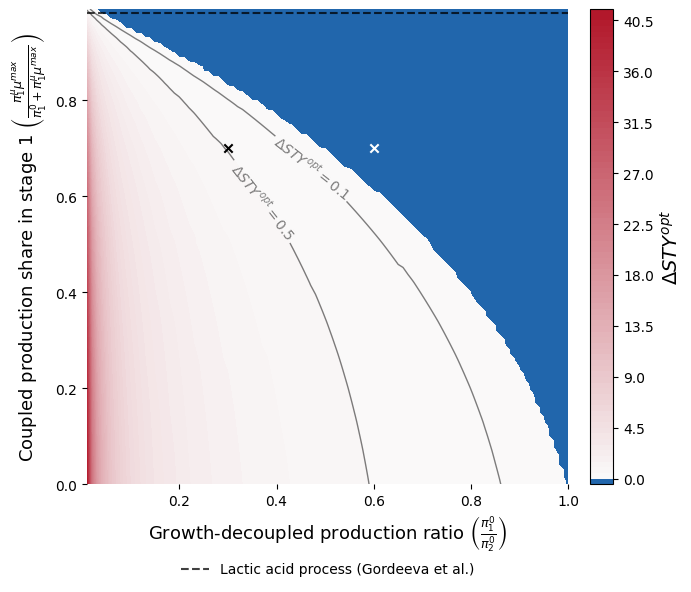

In [12]:
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm, Normalize


pivot = df.pivot_table(
    index='pi1_ratio', 
    columns='pi0_ratio', 
    values='TS_adv'
    )

z_min = pivot.values.min()
z_max = pivot.values.max()
z_range = z_max - z_min
fig, ax = plt.subplots(figsize=(7, 6))
blue = "#2166ac"
mid_color = "#fafafa"
red = "#b2182b"

z_min = pivot.values.min()
z_max = pivot.values.max()

if z_min < 0 and z_max > 0:
    # base with white at center = 0 
    cmap = LinearSegmentedColormap.from_list(
        "diverging",
        [blue, mid_color, red]
    )
    norm = TwoSlopeNorm(vmin=z_min, vcenter=0, vmax=z_max)

elif z_max <= 0:
    # only negative -> blue to white
    cmap = LinearSegmentedColormap.from_list(
        "neg",
        [blue, mid_color]
    )
    norm = Normalize(vmin=z_min, vmax=z_max)

elif z_min >= 0:
    # only positive -> white to red
    cmap = LinearSegmentedColormap.from_list(
        "pos",
        [mid_color, red]
    )
    norm = Normalize(vmin=z_min, vmax=z_max)
# ---- main field ----
cf = ax.contourf(
    pivot.columns,
    pivot.index,
    pivot.values,
    levels=100,
    cmap=cmap,
    norm = norm
)


LINE_STYLES = {
    "lactic": {
        "color": "black",
        "alpha": 0.75,
        "linestyle": "--",
        "linewidth": 1.5,
        "label": "Lactic acid process (Gordeeva et al.)"
    },
}

ax.plot(
    [pivot.columns.min(), pivot.columns.max()],
    [pi1_ratio, pi1_ratio],
    **LINE_STYLES["lactic"]

)

improv_10 = ax.contour(
    pivot.columns,
    pivot.index,
    pivot.values,
    levels=[0.1],
    colors="black",     
    alpha = 0.5,   
    linewidths=1,
    linestyles="-"
)

improv_50 = ax.contour(
    pivot.columns,
    pivot.index,
    pivot.values,
    levels=[0.5],
    colors="black",     
    alpha = 0.5,
    linewidths=1,
    linestyles="-"
)


ax.clabel(
    improv_10,
    fmt={0.1: r"$\Delta STY^{opt}=0.1$"},
    inline=True,
    fontsize=10,
    manual=[(0.5, 0.7)]
)

ax.clabel(
    improv_50,
    fmt={0.5: r"$\Delta STY^{opt}=0.5$"},
    inline=True,
    fontsize=10,
    manual=[(0.5, 0.7)]
)

x_os_better, y_os_better = 0.6, 0.7
x_ts_better, y_ts_better = 0.3, 0.7
pi1ratio_plot = 0.7
ax.scatter([x_os_better],[y_os_better], marker="x", color="white")
ax.scatter([x_ts_better], [y_ts_better], marker="x", color="black")

ax.set_xlabel(
    r"Growth-decoupled production ratio $\left(\frac{\pi^0_1}{\pi^0_2}\right)$",
    fontsize=13,
)
ax.set_ylabel(
    r"Coupled production share in stage 1 $\left(\frac{\pi^\mu_1 \mu^{max}}{\pi^0_1+\pi^\mu_1\mu^{max}}\right)$",
    fontsize=13,
)


ax.grid(False)

for spine in ax.spines.values():
    spine.set_visible(False)

cbar = plt.colorbar(cf, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label(r"$\Delta STY^{opt}$", fontsize=14)

ax.legend(
    loc="lower center",
    bbox_to_anchor=(0.5, -0.22),
    ncol=2,
    frameon=False
)

plt.tight_layout()

In [13]:
def calc_pi1_s1(params, pi0_s1, pi1_ratio):
    return pi1_ratio/(1 - pi1_ratio) * pi0_s1/params["mu_max"]


def calc_pi0_s2(pi0_s1, pi2_ratio):
    return pi0_s1/pi2_ratio


pi1_s1=calc_pi1_s1(params, params["pi0_s1"], pi1ratio_plot)

pi0_s2_OS=calc_pi0_s2(params["pi0_s1"], x_os_better)

pi0_s2_TS=calc_pi0_s2(params["pi0_s1"], x_ts_better)

# Find production rate where they are equal

pi0_s2_eq=calc_pi0_s2(params["pi0_s1"], 0.495)

pi0_s2_TS


0.06666666666666667

In [14]:
# now, create D_range plot for equal processes

params_eq = params.copy()
params_eq["pi1_s1"] = pi1_s1
params_eq["pi0_s2"] = pi0_s2_eq

model_eq = ContiModel(params_eq)
solver_eq = ContiSolver(model_eq)
plotter_eq= ContiPlotter(model_eq, solver_eq)
eq_plot=plotter_eq.plot_D_range()

In [15]:
eq_plot.data = tuple(
    trace for trace in eq_plot.data
    if trace.name != "Biomass (S1)"
)
domain = eq_plot.layout.xaxis.domain
center = (domain[0] + domain[1]) / 2
eq_plot.update_layout(
    width=600,
    height=375,
    legend = dict(
        x = center,
        xanchor = "center",
        xref = "paper",
        y = -0.25,
    )
)
eq_plot.show()

In [16]:
# now, create one D_range plot for the red, and one for the blue area.

params_os_better = params.copy()
params_os_better["pi1_s1"] = pi1_s1
params_os_better["pi0_s2"] = pi0_s2_OS

model_os_better = ContiModel(params_os_better)
solver_os_better = ContiSolver(model_os_better)
plotter_os_better = ContiPlotter(model_os_better, solver_os_better)
OS_plot=plotter_os_better.plot_D_range()




In [17]:
OS_plot.data = tuple(
    trace for trace in OS_plot.data
    if trace.name != "Biomass (S1)"
)
domain = OS_plot.layout.xaxis.domain
center = (domain[0] + domain[1]) / 2
OS_plot.update_layout(
    width=600,
    height=375,
    legend = dict(
        x = center,
        xanchor = "center",
        xref = "paper",
        y = -0.25,
    )
)
OS_plot.show()

In [18]:
# now, create one D_range plot for the red, and one for the blue area.

params_ts_better = params.copy()
params_ts_better["pi1_s1"] = pi1_s1
params_ts_better["pi0_s2"] = pi0_s2_TS

model_ts_better = ContiModel(params_ts_better)
solver_ts_better = ContiSolver(model_ts_better)
plotter_ts_better = ContiPlotter(model_ts_better, solver_ts_better)
TS_plot = plotter_ts_better.plot_D_range()

In [19]:
TS_plot.data = tuple(
    trace for trace in TS_plot.data
    if trace.name != "Biomass (S1)"
)
TS_plot.update_layout(
    width=600,
    height=375,
    legend = dict(
        x = center,
        xanchor = "center",
        xref = "paper",
        y = -0.25,
    )
)